# 🔍 NOTEBOOK 03: DATA QUALITY & CLEANING

**Objetivo:** Validar e limpar dados extraídos (Cartola + StatsBomb)  
**Input:** Bronze layer (raw data)  
**Output:** Silver layer (cleaned data)

In [1]:
# Setup
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from utils.config import (
    BRONZE_CARTOLA, BRONZE_STATSBOMB,
    SILVER_CARTOLA, SILVER_STATSBOMB,
    CARTOLA_POSITIONS,
    MAX_MISSING_PCT
)
from utils.logger import setup_logger

logger = setup_logger('data_quality', 'logs/data_quality.log')

# Config visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Setup completo!")

✅ Setup completo!


---
## 📥 1. CARREGAR DADOS BRUTOS

In [2]:
print("="*70)
print(" "*20 + "📥 CARREGANDO DADOS")
print("="*70 + "\n")

# CARTOLA
print("🇧🇷 CARTOLA FC:\n")

cartola_file = BRONZE_CARTOLA / 'atletas_all.parquet'

if cartola_file.exists():
    df_cartola = pd.read_parquet(cartola_file)
    print(f"✅ Atletas: {len(df_cartola):,} registros")
    print(f"   Colunas: {len(df_cartola.columns)}")
    print(f"   Memory: {df_cartola.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
else:
    print("❌ Arquivo não encontrado!")
    df_cartola = pd.DataFrame()

# STATSBOMB
print("\n🌍 STATSBOMB:\n")

statsbomb_matches = BRONZE_STATSBOMB / 'matches.parquet'
statsbomb_events = BRONZE_STATSBOMB / 'events_sample.parquet'

if statsbomb_matches.exists():
    df_matches = pd.read_parquet(statsbomb_matches)
    print(f"✅ Partidas: {len(df_matches):,} registros")
else:
    print("⚠️  Partidas não encontradas")
    df_matches = pd.DataFrame()

if statsbomb_events.exists():
    df_events = pd.read_parquet(statsbomb_events)
    print(f"✅ Eventos: {len(df_events):,} registros")
    print(f"   Memory: {df_events.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
else:
    print("⚠️  Eventos não encontrados")
    df_events = pd.DataFrame()

print("\n" + "="*70)

                    📥 CARREGANDO DADOS

🇧🇷 CARTOLA FC:

✅ Atletas: 692 registros
   Colunas: 22
   Memory: 0.76 MB

🌍 STATSBOMB:

✅ Partidas: 1,117 registros
✅ Eventos: 115,498 registros
   Memory: 335.83 MB



In [3]:
# CORREÇÃO: Remover colunas problemáticas antes de análise
print("🔧 Preparando dados para análise...\\n")

# Identificar colunas com dicts/lists
problematic_cols = []

for col in df_cartola.columns:
    if df_cartola[col].dtype == 'object':
        # Verificar se tem dicts/lists
        sample = df_cartola[col].dropna().iloc[0] if len(df_cartola[col].dropna()) > 0 else None
        if isinstance(sample, (dict, list)):
            problematic_cols.append(col)
            print(f"   ⚠️  Coluna '{col}' contém {type(sample).__name__}")

# Criar cópia sem colunas problemáticas
df_cartola_analysis = df_cartola.drop(columns=problematic_cols)

print(f"\\n✅ Colunas removidas para análise: {problematic_cols}")
print(f"✅ DataFrame pronto: {df_cartola_analysis.shape}")

🔧 Preparando dados para análise...\n
   ⚠️  Coluna 'scout' contém dict
\n✅ Colunas removidas para análise: ['scout']
✅ DataFrame pronto: (692, 21)


---
## 🔍 2. ANÁLISE DE QUALIDADE - CARTOLA

In [4]:
if not df_cartola.empty:
    
    # PREPARAR dados (remover colunas problemáticas)
    problematic_cols = []
    for col in df_cartola.columns:
        if df_cartola[col].dtype == 'object':
            sample = df_cartola[col].dropna().iloc[0] if len(df_cartola[col].dropna()) > 0 else None
            if isinstance(sample, (dict, list)):
                problematic_cols.append(col)
    
    df_cartola_analysis = df_cartola.drop(columns=problematic_cols)
    
    print("="*70)
    print(" "*15 + "🔍 DATA QUALITY - CARTOLA FC")
    print("="*70 + "\\n")
    
    # 1. Shape e tipos
    print("📊 ESTRUTURA:")
    print(f"   Shape: {df_cartola_analysis.shape}")
    print(f"   Dtypes únicos: {df_cartola_analysis.dtypes.value_counts().to_dict()}\\n")
    
    # 2. Missing values
    print("📊 MISSING VALUES:")
    missing = df_cartola_analysis.isnull().sum()
    missing_pct = (missing / len(df_cartola_analysis) * 100).round(2)
    
    missing_df = pd.DataFrame({
        'missing': missing,
        'pct': missing_pct
    })
    missing_df = missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)
    
    if len(missing_df) > 0:
        print(f"   Colunas com missing: {len(missing_df)}\\n")
        print(missing_df.head(10))
    else:
        print("   ✅ Sem missing values!")
    
    # 3. Duplicatas (AGORA FUNCIONA!)
    print(f"\\n📊 DUPLICATAS:")
    duplicates = df_cartola_analysis.duplicated().sum()
    print(f"   Total: {duplicates}")
    
    if duplicates > 0:
        print(f"   ⚠️  {duplicates} linhas duplicadas encontradas")
    
    # 4. Valores únicos em colunas chave
    print(f"\\n📊 VALORES ÚNICOS:")
    for col in ['temporada', 'rodada', 'posicao_id', 'clube_id']:
        if col in df_cartola_analysis.columns:
            print(f"   {col}: {df_cartola_analysis[col].nunique()} únicos")
    
    # 5. Estatísticas das colunas numéricas
    print(f"\\n📊 ESTATÍSTICAS (colunas numéricas):")
    numeric_cols = df_cartola_analysis.select_dtypes(include=[np.number]).columns
    print(df_cartola_analysis[numeric_cols].describe().round(2))
    
    logger.info(f"Cartola: {len(df_cartola_analysis)} registros, {duplicates} duplicatas")

else:
    print("❌ DataFrame Cartola vazio!")

               🔍 DATA QUALITY - CARTOLA FC
======================================================================\n
📊 ESTRUTURA:
   Shape: (692, 21)
   Dtypes únicos: {dtype('float64'): 7, dtype('O'): 7, dtype('int64'): 6, dtype('bool'): 1}\n
📊 MISSING VALUES:
   Colunas com missing: 3\n
                     missing     pct
pontos_rodadas_std       692  100.00
pontos_rodadas_mean      358   51.73
num_rodadas_jogou        358   51.73
\n📊 DUPLICATAS:
   Total: 0
\n📊 VALORES ÚNICOS:
   posicao_id: 6 únicos
   clube_id: 20 únicos
\n📊 ESTATÍSTICAS (colunas numéricas):
       jogos_num  atleta_id  rodada_id  clube_id  posicao_id  status_id  \
count     692.00     692.00      692.0    692.00      692.00     692.00   
mean        0.48  106176.71        1.0    372.18        3.55       5.96   
std         0.50   22795.93        0.0    412.46        1.34       1.18   
min         0.00   37656.00        1.0    262.00        1.00       2.00   
25%         0.00   90899.25        1.0    267.00       

---
## 🔍 3. ANÁLISE DE QUALIDADE - STATSBOMB

In [5]:
if not df_matches.empty:
    
    print("="*70)
    print(" "*15 + "🔍 DATA QUALITY - STATSBOMB")
    print("="*70 + "\n")
    
    # 1. Partidas
    print("⚽ PARTIDAS:")
    print(f"   Total: {len(df_matches):,}")
    print(f"   Competições: {df_matches['competition_name'].nunique()}")
    print(f"   Temporadas: {df_matches['season_name'].nunique()}\n")
    
    # Missing values
    print("📊 MISSING VALUES (top 10):")
    missing = df_matches.isnull().sum()
    missing_pct = (missing / len(df_matches) * 100).round(2)
    
    missing_df = pd.DataFrame({
        'missing': missing,
        'pct': missing_pct
    })
    missing_df = missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)
    print(missing_df.head(10))
    
    # Duplicatas
    duplicates = df_matches.duplicated(subset=['match_id']).sum()
    print(f"\n📊 DUPLICATAS: {duplicates}")
    
    logger.info(f"StatsBomb Matches: {len(df_matches)} registros")

if not df_events.empty:
    
    print("\n📊 EVENTOS:")
    print(f"   Total: {len(df_events):,}")
    print(f"   Tipos: {df_events['type'].nunique()}")
    print(f"   Partidas: {df_events['match_id'].nunique()}\n")
    
    # Top tipos de evento
    print("📊 TOP 10 TIPOS DE EVENTO:")
    print(df_events['type'].value_counts().head(10))
    
    logger.info(f"StatsBomb Events: {len(df_events)} registros")

               🔍 DATA QUALITY - STATSBOMB

⚽ PARTIDAS:
   Total: 1,117
   Competições: 3
   Temporadas: 28

📊 MISSING VALUES (top 10):
                       missing    pct
last_updated_360           365  32.68
referee                    113  10.12
xy_fidelity_version         90   8.06
shot_fidelity_version       64   5.73

📊 DUPLICATAS: 0
2026-02-05 17:46:10 | data_quality | INFO | StatsBomb Matches: 1117 registros

📊 EVENTOS:
   Total: 115,498
   Tipos: 33
   Partidas: 30

📊 TOP 10 TIPOS DE EVENTO:
type
Pass             33489
Ball Receipt*    31735
Carry            26933
Pressure          8642
Ball Recovery     2604
Duel              1887
Block             1183
Clearance         1118
Goal Keeper        931
Dribble            918
Name: count, dtype: int64
2026-02-05 17:46:10 | data_quality | INFO | StatsBomb Events: 115498 registros


---
## 🧹 4. LIMPEZA - CARTOLA

In [6]:
if not df_cartola.empty:
    
    print("="*70)
    print(" "*20 + "🧹 LIMPEZA - CARTOLA")
    print("="*70 + "\\n")
    
    # PASSO 0: Remover colunas com dicts/lists (NÃO PODEM SER USADAS)
    print("🔧 Preparando dados para limpeza...\\n")
    
    cols_to_drop = []
    for col in df_cartola.columns:
        if df_cartola[col].dtype == 'object':
            try:
                # Pegar amostra
                sample = df_cartola[col].dropna()
                if len(sample) > 0:
                    first_val = sample.iloc[0]
                    if isinstance(first_val, (dict, list)):
                        cols_to_drop.append(col)
                        print(f"   ⚠️  Removendo '{col}' (contém {type(first_val).__name__})")
            except:
                pass
    
    # Criar cópia sem colunas problemáticas
    df_cartola_clean = df_cartola.drop(columns=cols_to_drop, errors='ignore')
    
    print(f"\\n📊 Colunas removidas: {len(cols_to_drop)}")
    print(f"📊 Colunas restantes: {len(df_cartola_clean.columns)}\\n")
    print(f"📊 Registros iniciais: {len(df_cartola_clean):,}\\n")
    
    # 1. Remover duplicatas
    before = len(df_cartola_clean)
    df_cartola_clean = df_cartola_clean.drop_duplicates()
    after = len(df_cartola_clean)
    print(f"1️⃣  Duplicatas removidas: {before - after}")
    
    # 2. Adicionar nome da posição (se não existir)
    if 'posicao_nome' not in df_cartola_clean.columns and 'posicao_id' in df_cartola_clean.columns:
        df_cartola_clean['posicao_nome'] = df_cartola_clean['posicao_id'].map(CARTOLA_POSITIONS)
        print(f"2️⃣  Coluna 'posicao_nome' adicionada")
    
    # 3. Converter tipos de dados
    if 'temporada' in df_cartola_clean.columns:
        df_cartola_clean['temporada'] = df_cartola_clean['temporada'].astype('int16')
    
    if 'rodada' in df_cartola_clean.columns:
        df_cartola_clean['rodada'] = df_cartola_clean['rodada'].astype('int8')
    
    print(f"3️⃣  Tipos de dados otimizados")
    
    # 4. Tratar missing values em colunas numéricas
    stat_cols = ['pontos_num', 'media_num', 'jogos_num', 'preco_num']
    filled_count = 0
    
    for col in stat_cols:
        if col in df_cartola_clean.columns:
            missing_before = df_cartola_clean[col].isnull().sum()
            if missing_before > 0:
                df_cartola_clean[col] = df_cartola_clean[col].fillna(0)
                filled_count += missing_before
    
    print(f"4️⃣  Missing values preenchidos: {filled_count}")
    
    # 5. Validar ranges (remover outliers extremos)
    if 'pontos_num' in df_cartola_clean.columns:
        before = len(df_cartola_clean)
        # Aceitar pontos entre -10 e 50 (remover erros da API)
        df_cartola_clean = df_cartola_clean[
            (df_cartola_clean['pontos_num'] >= -10) & 
            (df_cartola_clean['pontos_num'] <= 50)
        ]
        after = len(df_cartola_clean)
        print(f"5️⃣  Outliers extremos removidos: {before - after}")
    
    print(f"\\n✅ Registros finais: {len(df_cartola_clean):,}")
    print(f"📊 Redução total: {len(df_cartola) - len(df_cartola_clean)} registros ({(1 - len(df_cartola_clean)/len(df_cartola))*100:.1f}%)")
    
    logger.info(f"Cartola limpo: {len(df_cartola_clean)} registros")

else:
    df_cartola_clean = pd.DataFrame()
    print("❌ DataFrame Cartola vazio!")

                    🧹 LIMPEZA - CARTOLA
======================================================================\n
🔧 Preparando dados para limpeza...\n
   ⚠️  Removendo 'scout' (contém dict)
\n📊 Colunas removidas: 1
📊 Colunas restantes: 21\n
📊 Registros iniciais: 692\n
1️⃣  Duplicatas removidas: 0
3️⃣  Tipos de dados otimizados
4️⃣  Missing values preenchidos: 0
5️⃣  Outliers extremos removidos: 0
\n✅ Registros finais: 692
📊 Redução total: 0 registros (0.0%)
2026-02-05 17:46:17 | data_quality | INFO | Cartola limpo: 692 registros


---
## 🧹 5. LIMPEZA - STATSBOMB

In [7]:
if not df_matches.empty:
    
    print("="*70)
    print(" "*20 + "🧹 LIMPEZA - STATSBOMB")
    print("="*70 + "\\n")
    
    # PASSO 0: Remover colunas problemáticas
    print("🔧 Preparando dados StatsBomb...\\n")
    
    cols_to_drop_matches = []
    for col in df_matches.columns:
        try:
            sample = df_matches[col].dropna()
            if len(sample) > 0:
                first_val = sample.iloc[0]
                if isinstance(first_val, (dict, list, np.ndarray)):
                    cols_to_drop_matches.append(col)
                    print(f"   ⚠️  Removendo '{col}' de matches (contém {type(first_val).__name__})")
        except:
            pass
    
    df_matches_clean = df_matches.drop(columns=cols_to_drop_matches, errors='ignore')
    
    print(f"\\n📊 Partidas iniciais: {len(df_matches_clean):,}\\n")
    
    # 1. Remover duplicatas por match_id
    before = len(df_matches_clean)
    df_matches_clean = df_matches_clean.drop_duplicates(subset=['match_id'])
    after = len(df_matches_clean)
    print(f"1️⃣  Duplicatas removidas: {before - after}")
    
    # 2. Converter datas
    if 'match_date' in df_matches_clean.columns:
        df_matches_clean['match_date'] = pd.to_datetime(df_matches_clean['match_date'], errors='coerce')
        print(f"2️⃣  Datas convertidas")
    
    # 3. Adicionar features úteis
    if 'home_score' in df_matches_clean.columns and 'away_score' in df_matches_clean.columns:
        df_matches_clean['total_goals'] = df_matches_clean['home_score'] + df_matches_clean['away_score']
        df_matches_clean['goal_diff'] = df_matches_clean['home_score'] - df_matches_clean['away_score']
        
        # Resultado
        df_matches_clean['result'] = 'Draw'
        df_matches_clean.loc[df_matches_clean['goal_diff'] > 0, 'result'] = 'Home Win'
        df_matches_clean.loc[df_matches_clean['goal_diff'] < 0, 'result'] = 'Away Win'
        
        print(f"3️⃣  Features adicionadas (total_goals, result)")
    
    print(f"\\n✅ Partidas finais: {len(df_matches_clean):,}")
    
    logger.info(f"StatsBomb Matches limpo: {len(df_matches_clean)} registros")

else:
    df_matches_clean = pd.DataFrame()

# EVENTOS (limpeza básica)
if not df_events.empty:
    
    print(f"\\n🔧 Preparando eventos StatsBomb...\\n")
    
    # Remover colunas problemáticas
    cols_to_drop_events = []
    for col in df_events.columns:
        try:
            sample = df_events[col].dropna()
            if len(sample) > 0:
                first_val = sample.iloc[0]
                if isinstance(first_val, (dict, list, np.ndarray)):
                    cols_to_drop_events.append(col)
                    print(f"   ⚠️  Removendo '{col}' de eventos (contém {type(first_val).__name__})")
        except:
            pass
    
    df_events_clean = df_events.drop(columns=cols_to_drop_events, errors='ignore')
    
    # Remover duplicatas
    before = len(df_events_clean)
    df_events_clean = df_events_clean.drop_duplicates()
    after = len(df_events_clean)
    
    print(f"\\n📊 EVENTOS:")
    print(f"   Colunas removidas: {len(cols_to_drop_events)}")
    print(f"   Duplicatas removidas: {before - after}")
    print(f"   Registros finais: {len(df_events_clean):,}")
    
    logger.info(f"StatsBomb Events limpo: {len(df_events_clean)} registros")

else:
    df_events_clean = pd.DataFrame()

                    🧹 LIMPEZA - STATSBOMB
======================================================================\n
🔧 Preparando dados StatsBomb...\n
\n📊 Partidas iniciais: 1,117\n
1️⃣  Duplicatas removidas: 0
2️⃣  Datas convertidas
3️⃣  Features adicionadas (total_goals, result)
\n✅ Partidas finais: 1,117
2026-02-05 17:46:33 | data_quality | INFO | StatsBomb Matches limpo: 1117 registros
\n🔧 Preparando eventos StatsBomb...\n
   ⚠️  Removendo 'carry_end_location' de eventos (contém ndarray)
   ⚠️  Removendo 'goalkeeper_end_location' de eventos (contém ndarray)
   ⚠️  Removendo 'location' de eventos (contém ndarray)
   ⚠️  Removendo 'pass_end_location' de eventos (contém ndarray)
   ⚠️  Removendo 'related_events' de eventos (contém ndarray)
   ⚠️  Removendo 'shot_end_location' de eventos (contém ndarray)
   ⚠️  Removendo 'shot_freeze_frame' de eventos (contém ndarray)
   ⚠️  Removendo 'tactics' de eventos (contém dict)
   ⚠️  Removendo '50_50' de eventos (contém dict)
\n📊 EVENTOS:
   Col

---
## 📊 6. VISUALIZAÇÕES DE QUALIDADE

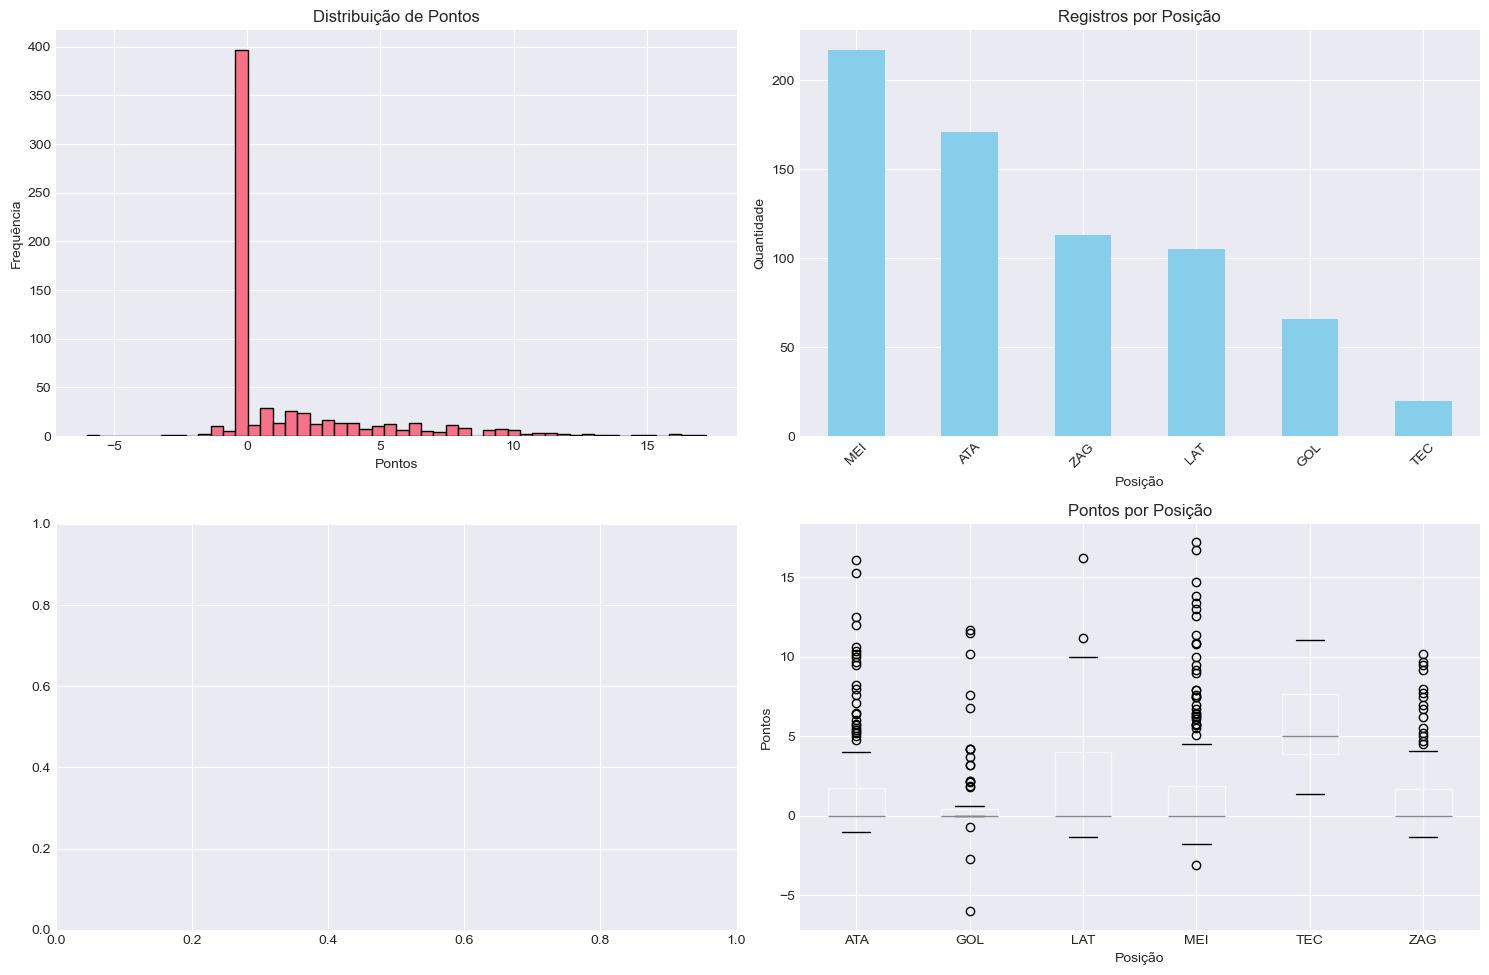

✅ Visualizações geradas!


In [8]:
if not df_cartola_clean.empty:
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('📊 DATA QUALITY - CARTOLA FC', fontsize=16, fontweight='bold')
    
    # 1. Distribuição de pontos
    if 'pontos_num' in df_cartola_clean.columns:
        df_cartola_clean['pontos_num'].hist(bins=50, ax=axes[0,0], edgecolor='black')
        axes[0,0].set_title('Distribuição de Pontos')
        axes[0,0].set_xlabel('Pontos')
        axes[0,0].set_ylabel('Frequência')
    
    # 2. Jogadores por posição
    if 'posicao_nome' in df_cartola_clean.columns:
        df_cartola_clean['posicao_nome'].value_counts().plot(kind='bar', ax=axes[0,1], color='skyblue')
        axes[0,1].set_title('Registros por Posição')
        axes[0,1].set_xlabel('Posição')
        axes[0,1].set_ylabel('Quantidade')
        axes[0,1].tick_params(axis='x', rotation=45)
    
    # 3. Registros por temporada
    if 'temporada' in df_cartola_clean.columns:
        df_cartola_clean['temporada'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='green')
        axes[1,0].set_title('Registros por Temporada')
        axes[1,0].set_xlabel('Temporada')
        axes[1,0].set_ylabel('Quantidade')
    
    # 4. Boxplot de pontos por posição
    if 'pontos_num' in df_cartola_clean.columns and 'posicao_nome' in df_cartola_clean.columns:
        df_cartola_clean.boxplot(column='pontos_num', by='posicao_nome', ax=axes[1,1])
        axes[1,1].set_title('Pontos por Posição')
        axes[1,1].set_xlabel('Posição')
        axes[1,1].set_ylabel('Pontos')
        plt.suptitle('')  # Remover título duplicado do boxplot
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizações geradas!")

---
## 💾 7. SALVAR DADOS LIMPOS (SILVER LAYER)

In [9]:
print("="*70)
print(" "*20 + "💾 SALVANDO - SILVER LAYER")
print("="*70 + "\n")

# Criar diretórios
SILVER_CARTOLA.mkdir(parents=True, exist_ok=True)
SILVER_STATSBOMB.mkdir(parents=True, exist_ok=True)

# Salvar Cartola
if not df_cartola_clean.empty:
    output = SILVER_CARTOLA / 'atletas_clean.parquet'
    df_cartola_clean.to_parquet(output, compression='snappy', index=False)
    
    size_mb = output.stat().st_size / (1024 * 1024)
    
    print(f"✅ CARTOLA:")
    print(f"   📁 {output}")
    print(f"   📊 {len(df_cartola_clean):,} registros")
    print(f"   📦 {size_mb:.2f} MB\n")
    
    logger.info(f"Cartola Silver salvou: {len(df_cartola_clean)} registros")

# Salvar StatsBomb - Partidas
if not df_matches_clean.empty:
    output = SILVER_STATSBOMB / 'matches_clean.parquet'
    df_matches_clean.to_parquet(output, compression='snappy', index=False)
    
    size_mb = output.stat().st_size / (1024 * 1024)
    
    print(f"✅ STATSBOMB - PARTIDAS:")
    print(f"   📁 {output}")
    print(f"   📊 {len(df_matches_clean):,} registros")
    print(f"   📦 {size_mb:.2f} MB\n")
    
    logger.info(f"StatsBomb Matches Silver: {len(df_matches_clean)} registros")

# Salvar StatsBomb - Eventos
if not df_events_clean.empty:
    output = SILVER_STATSBOMB / 'events_clean.parquet'
    df_events_clean.to_parquet(output, compression='snappy', index=False)
    
    size_mb = output.stat().st_size / (1024 * 1024)
    
    print(f"✅ STATSBOMB - EVENTOS:")
    print(f"   📁 {output}")
    print(f"   📊 {len(df_events_clean):,} registros")
    print(f"   📦 {size_mb:.2f} MB\n")
    
    logger.info(f"StatsBomb Events Silver: {len(df_events_clean)} registros")

print("="*70)

                    💾 SALVANDO - SILVER LAYER

✅ CARTOLA:
   📁 D:\football analytics project\data\silver\cartola\atletas_clean.parquet
   📊 692 registros
   📦 0.06 MB

2026-02-05 17:46:59 | data_quality | INFO | Cartola Silver salvou: 692 registros
✅ STATSBOMB - PARTIDAS:
   📁 D:\football analytics project\data\silver\statsbomb\matches_clean.parquet
   📊 1,117 registros
   📦 0.07 MB

2026-02-05 17:46:59 | data_quality | INFO | StatsBomb Matches Silver: 1117 registros
✅ STATSBOMB - EVENTOS:
   📁 D:\football analytics project\data\silver\statsbomb\events_clean.parquet
   📊 115,498 registros
   📦 7.02 MB

2026-02-05 17:47:00 | data_quality | INFO | StatsBomb Events Silver: 115498 registros


---
## 📋 8. RESUMO FINAL

In [10]:
print("\n" + "="*70)
print(" "*15 + "🎉 NOTEBOOK 03 - LIMPEZA CONCLUÍDA!")
print("="*70 + "\n")

print("📊 RESUMO:\n")

# Cartola
if not df_cartola_clean.empty:
    print("🇧🇷 CARTOLA FC:")
    print(f"   Bronze → Silver: {len(df_cartola):,} → {len(df_cartola_clean):,}")
    print(f"   Redução: {len(df_cartola) - len(df_cartola_clean)} registros")
    print(f"   Taxa de aproveitamento: {len(df_cartola_clean)/len(df_cartola)*100:.1f}%\n")

# StatsBomb
if not df_matches_clean.empty:
    print("🌍 STATSBOMB:")
    print(f"   Partidas: {len(df_matches):,} → {len(df_matches_clean):,}")
    if not df_events_clean.empty:
        print(f"   Eventos: {len(df_events):,} → {len(df_events_clean):,}")
    print(f"   Taxa de aproveitamento: {len(df_matches_clean)/len(df_matches)*100:.1f}%\n")

print("📁 Arquivos salvos em:")
print(f"   📂 {SILVER_CARTOLA}/")
print(f"   📂 {SILVER_STATSBOMB}/\n")

print("="*70)
print("📌 PRÓXIMO PASSO: Notebook 04 - EDA & Feature Engineering")
print("="*70)

logger.info("Notebook 03 - Data Quality concluído")


               🎉 NOTEBOOK 03 - LIMPEZA CONCLUÍDA!

📊 RESUMO:

🇧🇷 CARTOLA FC:
   Bronze → Silver: 692 → 692
   Redução: 0 registros
   Taxa de aproveitamento: 100.0%

🌍 STATSBOMB:
   Partidas: 1,117 → 1,117
   Eventos: 115,498 → 115,498
   Taxa de aproveitamento: 100.0%

📁 Arquivos salvos em:
   📂 D:\football analytics project\data\silver\cartola/
   📂 D:\football analytics project\data\silver\statsbomb/

📌 PRÓXIMO PASSO: Notebook 04 - EDA & Feature Engineering
2026-02-05 17:47:05 | data_quality | INFO | Notebook 03 - Data Quality concluído
